# Augmentation Comparison Analysis

Compare feature space distributions of augmentation strategies against original and test datasets using a frozen YOLO backbone.

**Groups Compared:**
1. Original Train - baseline training data
2. Augmented (Score) - score-guided augmentation
3. Random Aug - random augmentation  
4. Test - held-out test set

**Steps:**
1. Provide paths to all four datasets
2. Extract image-level embeddings from YOLO feature maps
3. Visualize 2D PCA projection with all groups
4. Compute pairwise centroid distances
5. Compare augmentation methods relative to test set


In [22]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import random
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from ultralytics import YOLO

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [23]:
# ---------------------------
# User Inputs: Modify these paths
# ---------------------------

# Path to original training dataset
PATH_ORIGINAL = Path("/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/images")

# Path to augmented (score-guided) augmentation dataset
PATH_AUGMENTED_AUG = Path("/home/khanh/Projects/DifficultyAgri/results/09_aug_exp_only/seed_123/Step_4_Copy_Paste_Augmentation/augmented_dataset/train/images")

# Path to random augmentation dataset
PATH_RANDOM_AUG = Path("/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/new_dataset/random/seed_123/images")

# Path to test dataset
PATH_TEST = Path("/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/images")

# YOLO backbone checkpoint for feature extraction (frozen)
PROJECT_ROOT = Path("/home/khanh/Projects/DifficultyAgri")
YOLO_WEIGHTS = PROJECT_ROOT / "finetuned_baseline_model/yolov8s.pt"


# Configuration

FEATURE_LEVEL = "P5"  # "P3", "P4", or "P5"RANDOM_SEED = 123

IMAGE_SIZE = 1024
MAX_IMAGES_PER_GROUP = None  # None for all; set to int to limit (e.g., 500)

In [24]:
# Helper functions
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
rng = random.Random(RANDOM_SEED)


def list_image_paths(directory: Path) -> list[Path]:
    """Load all images from a directory recursively."""
    if not directory.exists():
        print(f"Warning: Directory does not exist: {directory}")
        return []
    images = sorted([p for p in directory.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])
    return images


def sample_paths(paths: list[Path], max_count: int | None) -> list[Path]:
    """Randomly sample image paths if exceeding max_count."""
    if max_count is None or len(paths) <= max_count:
        return paths
    idx = list(range(len(paths)))
    rng.shuffle(idx)
    keep = set(idx[:max_count])
    return [p for i, p in enumerate(paths) if i in keep]


In [25]:
# Load images from the four dataset paths
group_to_paths: dict[str, list[Path]] = {
    "Original Train": sample_paths(list_image_paths(PATH_ORIGINAL), MAX_IMAGES_PER_GROUP),
    "Augmented (Score)": sample_paths(list_image_paths(PATH_AUGMENTED_AUG), MAX_IMAGES_PER_GROUP),
    "Random Aug": sample_paths(list_image_paths(PATH_RANDOM_AUG), MAX_IMAGES_PER_GROUP),
    "Test": sample_paths(list_image_paths(PATH_TEST), MAX_IMAGES_PER_GROUP),
}

# Display summary
counts_df = pd.DataFrame({
    "Group": list(group_to_paths.keys()),
    "Count": [len(v) for v in group_to_paths.values()],
})
print("Dataset Summary:")
display(counts_df)

# Validate
if any(len(v) == 0 for v in group_to_paths.values()):

    raise RuntimeError("At least one group has 0 images. Check your input paths!")

Dataset Summary:


,Group,Count
0,Original Train,536
1,Augmented (Score),690
2,Random Aug,804
3,Test,331


In [26]:
# Initialize YOLO model for feature extraction
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

yolo = YOLO(str(YOLO_WEIGHTS))
model = yolo.model.to(device).eval()
for p in model.parameters():
    p.requires_grad = False

# Identify the requested feature level
detect_module = model.model[-1]
detect_feature_from = list(getattr(detect_module, "f", []))
if len(detect_feature_from) < 3:
    raise RuntimeError("Could not resolve Detect feature indices.")

feature_index_map = {
    "P3": int(detect_feature_from[-3]),
    "P4": int(detect_feature_from[-2]),
    "P5": int(detect_feature_from[-1]),
}

if FEATURE_LEVEL not in feature_index_map:
    raise ValueError(f"FEATURE_LEVEL must be one of {list(feature_index_map.keys())}")

TARGET_LAYER_INDEX = feature_index_map[FEATURE_LEVEL]
print(f"Extracting features from layer {FEATURE_LEVEL} (model.model[{TARGET_LAYER_INDEX}])")


Using device: cuda
Extracting features from layer P5 (model.model[21])


In [27]:
def preprocess_image_for_yolo(image_path: Path, image_size: int = 1024) -> torch.Tensor:
    img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise RuntimeError(f"Failed to read image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)

    x = torch.from_numpy(img_resized).float() / 255.0
    x = x.permute(2, 0, 1).unsqueeze(0)
    return x


def extract_image_embedding(model, image_path: Path, layer_index: int, image_size: int, device: torch.device) -> np.ndarray:
    captured = {}

    def hook_fn(_module, _inputs, output):
        if isinstance(output, (tuple, list)):
            output = output[0]
        captured["feat"] = output

    handle = model.model[layer_index].register_forward_hook(hook_fn)

    try:
        x = preprocess_image_for_yolo(image_path, image_size=image_size).to(device)
        with torch.no_grad():
            _ = model(x)

        feat = captured.get("feat", None)
        if feat is None:
            raise RuntimeError(f"Hook did not capture features for {image_path}")

        if feat.ndim == 4:
            emb = feat.mean(dim=(2, 3)).squeeze(0)
        elif feat.ndim == 2:
            emb = feat.squeeze(0)
        else:
            emb = feat.reshape(feat.shape[0], -1).mean(dim=0)

        return emb.detach().cpu().numpy().astype(np.float32)
    finally:
        handle.remove()

In [28]:
# Extract embeddings for all images
records = []

for group_name, paths in group_to_paths.items():
    print(f"\nExtracting embeddings: {group_name} ({len(paths)} images)")
    for i, img_path in enumerate(paths, start=1):
        if i % max(1, len(paths) // 5) == 0 or i == len(paths):
            print(f"  {i}/{len(paths)}")
        try:
            emb = extract_image_embedding(
                model=model,
                image_path=img_path,
                layer_index=TARGET_LAYER_INDEX,
                image_size=IMAGE_SIZE,
                device=device,
            )
            records.append({
                "group": group_name,
                "image_path": str(img_path),
                "embedding": emb,
            })
        except Exception as e:
            print(f"  Failed to extract from {img_path.name}: {e}")

print(f"\n✓ Extracted {len(records)} embeddings total")



Extracting embeddings: Original Train (536 images)
  107/536
  214/536
  321/536
  428/536
  535/536
  536/536

Extracting embeddings: Augmented (Score) (690 images)
  138/690
  276/690
  414/690
  552/690
  690/690

Extracting embeddings: Random Aug (804 images)
  160/804
  320/804
  480/804
  640/804
  800/804
  804/804

Extracting embeddings: Test (331 images)
  66/331
  132/331
  198/331
  264/331
  330/331
  331/331

✓ Extracted 2361 embeddings total


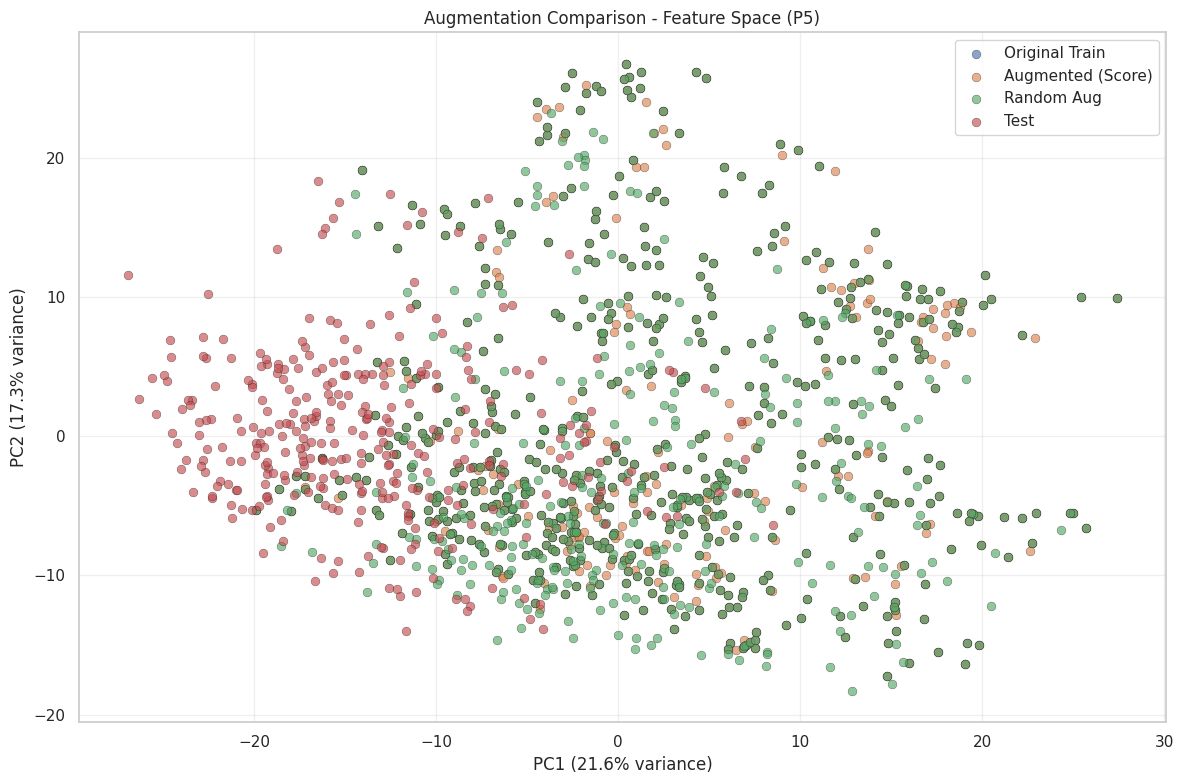


PCA explained variance (2D): 0.389


In [29]:
# PCA dimensionality reduction and visualization
if not records:
    raise RuntimeError("No embeddings extracted.")

meta_df = pd.DataFrame([{"group": r["group"], "image_path": r["image_path"]} for r in records])
X = np.stack([r["embedding"] for r in records], axis=0)

# Standardize and reduce to 2D
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_2d = pca.fit_transform(X_scaled)

# Create visualization dataframe
plot_df = meta_df.copy()
plot_df["PC1"] = X_2d[:, 0]
plot_df["PC2"] = X_2d[:, 1]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
for group in plot_df["group"].unique():
    mask = plot_df["group"] == group
    ax.scatter(plot_df[mask]["PC1"], plot_df[mask]["PC2"], 
              label=group, alpha=0.65, s=40, edgecolors='k', linewidth=0.3)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title(f"Augmentation Comparison - Feature Space ({FEATURE_LEVEL})")
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

total_var = pca.explained_variance_ratio_.sum()
print(f"\nPCA explained variance (2D): {total_var:.3f}")


In [30]:
# Compute centroids and inter-group distances
from sklearn.metrics import pairwise_distances

groups = list(group_to_paths.keys())
group_names = [g for g in groups]

centroids = {}
group_indices = {}

for g in group_names:
    idx = np.where(meta_df["group"].values == g)[0]
    if len(idx) == 0:
        raise RuntimeError(f"No embeddings for group: {g}")
    group_indices[g] = idx
    centroids[g] = X_scaled[idx].mean(axis=0)

def compute_dist(a: np.ndarray, b: np.ndarray, metric: str = "euclidean") -> float:
    return float(pairwise_distances(a[None, :], b[None, :], metric=metric)[0, 0])

# Pairwise centroid distances (Euclidean)
print("\n=== Pairwise Centroid Distances (Euclidean) ===")
dist_matrix_eu = np.zeros((len(group_names), len(group_names)))
for i, g1 in enumerate(group_names):
    for j, g2 in enumerate(group_names):
        dist_matrix_eu[i, j] = compute_dist(centroids[g1], centroids[g2], metric="euclidean")

dist_df_eu = pd.DataFrame(dist_matrix_eu, index=group_names, columns=group_names)
display(dist_df_eu.round(4))

# Pairwise centroid distances (Cosine)
print("\n=== Pairwise Centroid Distances (Cosine) ===")
dist_matrix_cos = np.zeros((len(group_names), len(group_names)))
for i, g1 in enumerate(group_names):
    for j, g2 in enumerate(group_names):
        dist_matrix_cos[i, j] = compute_dist(centroids[g1], centroids[g2], metric="cosine")

dist_df_cos = pd.DataFrame(dist_matrix_cos, index=group_names, columns=group_names)
display(dist_df_cos.round(4))

# Within-group dispersions
within_group_var = []
for g in group_names:
    idx = group_indices[g]
    dists = pairwise_distances(X_scaled[idx], metric="euclidean")
    within_group_var.append(dists.mean())

dispersion_df = pd.DataFrame({
    "Group": group_names,
    "Avg Within-Group Distance": [f"{v:.4f}" for v in within_group_var],
})

print("\n=== Within-Group Dispersion ===")
display(dispersion_df)



=== Pairwise Centroid Distances (Euclidean) ===


,Original Train,Augmented (Score),Random Aug,Test
Original Train,0.0000,0.7272,1.9672,17.3875
Augmented (Score),0.7272,0.0000,2.2974,17.6241
Random Aug,1.9672,2.2974,0.0000,17.0397
Test,17.3875,17.6241,17.0397,0.0000



=== Pairwise Centroid Distances (Cosine) ===


,Original Train,Augmented (Score),Random Aug,Test
Original Train,0.0000,0.0294,0.3002,1.9591
Augmented (Score),0.0294,0.0000,0.3568,1.9399
Random Aug,0.3002,0.3568,0.0000,1.8616
Test,1.9591,1.9399,1.8616,0.0000



=== Within-Group Dispersion ===


,Group,Avg Within-Group Distance
0,Original Train,30.5296
1,Augmented (Score),30.4947
2,Random Aug,30.4286
3,Test,27.6307


In [31]:
# Interpretation and summary
print("\n" + "="*70)
print("ANALYSIS SUMMARY: Feature Space Comparison")
print("="*70)

# Comparison to test set
print("\n📊 DISTANCE TO TEST SET (Euclidean):")
test_idx = group_names.index("Test")
for i, g in enumerate(group_names):
    if g != "Test":
        dist_to_test = dist_matrix_eu[i, test_idx]
        original_idx = group_names.index("Original Train")
        original_to_test = dist_matrix_eu[original_idx, test_idx]
        diff = dist_to_test - original_to_test
        symbol = "↑" if diff > 0 else "↓" if diff < 0 else "="
        print(f"   {g:20s} → Test: {dist_to_test:.4f}  (Δ {diff:+.4f}) {symbol}")

# Augmentation methods comparison
print("\n🔄 AUGMENTATION METHODS COMPARISON:")
aug_score_idx = group_names.index("Augmented (Score)")
random_aug_idx = group_names.index("Random Aug")
dist_between_augs = dist_matrix_eu[aug_score_idx, random_aug_idx]
print(f"   Distance between Augmented (Score) and Random Aug: {dist_between_augs:.4f}")

# Compactness analysis
print("\n📐 DISTRIBUTION COMPACTNESS (Within-group dispersion):")
for g, v in zip(group_names, within_group_var):
    print(f"   {g:20s}: {v:.4f}")

# Separation quality
print("\n✓ INTERPRETATION:")
original_to_test = dist_matrix_eu[group_names.index("Original Train"), test_idx]
aug_score_to_test = dist_matrix_eu[aug_score_idx, test_idx]
random_to_test = dist_matrix_eu[random_aug_idx, test_idx]

print(f"   Original Train remains {original_to_test:.4f} from Test (baseline)")
if aug_score_to_test < original_to_test:
    print(f"   ✓ Score-guided Aug is CLOSER to Test than Original")
else:
    print(f"   ✗ Score-guided Aug is FARTHER from Test than Original")

if random_to_test < original_to_test:
    print(f"   ✓ Random Aug is CLOSER to Test than Original")
else:
    print(f"   ✗ Random Aug is FARTHER from Test than Original")

if abs(aug_score_to_test - random_to_test) < 0.05:
    print(f"   → Augmentation methods have similar test proximity")
else:
    closer = "Score-guided" if aug_score_to_test < random_to_test else "Random"
    print(f"   → {closer} Aug is closer to Test set")



ANALYSIS SUMMARY: Feature Space Comparison

📊 DISTANCE TO TEST SET (Euclidean):
   Original Train       → Test: 17.3875  (Δ +0.0000) =
   Augmented (Score)    → Test: 17.6241  (Δ +0.2366) ↑
   Random Aug           → Test: 17.0397  (Δ -0.3478) ↓

🔄 AUGMENTATION METHODS COMPARISON:
   Distance between Augmented (Score) and Random Aug: 2.2974

📐 DISTRIBUTION COMPACTNESS (Within-group dispersion):
   Original Train      : 30.5296
   Augmented (Score)   : 30.4947
   Random Aug          : 30.4286
   Test                : 27.6307

✓ INTERPRETATION:
   Original Train remains 17.3875 from Test (baseline)
   ✗ Score-guided Aug is FARTHER from Test than Original
   ✓ Random Aug is CLOSER to Test than Original
   → Random Aug is closer to Test set
